# 01 - Univariate Hawkes Processes

A **Hawkes process** is a self-exciting point process: every event transiently
raises the probability of further events. Its conditional intensity is

$$\lambda(t) = \mu + \sum_{t_i < t} \varphi(t - t_i),$$

where $\mu > 0$ is the constant **background rate** and $\varphi$ is the
**triggering kernel**. With the exponential kernel
$\varphi(t) = \alpha\beta e^{-\beta t}$ used here, two numbers control the
dynamics:

* $\alpha = \int_0^\infty \varphi(t)\,dt$ -- the **branching ratio**, i.e. the
  expected number of children each event triggers. Stationarity requires
  $\alpha < 1$.
* $\beta$ -- the decay rate; $1/\beta$ is the excitation time constant.

This notebook simulates a process, fits it by maximum likelihood, interprets
the parameters, checks goodness of fit, and quantifies uncertainty.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import intensify as it

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.titlesize": 13})

rng = np.random.default_rng(0)
print(f"intensify {it.__version__}")

intensify 0.3.3


## 1. Simulate a process

We pick a moderately self-exciting process ($\alpha = 0.5$) with a background
rate of $\mu = 0.3$ events/s. For a stationary Hawkes process the long-run
rate is $\mu / (1 - \alpha)$, so we expect about $0.3 / 0.5 = 0.6$ events/s.

In [2]:
MU_TRUE, ALPHA_TRUE, BETA_TRUE = 0.3, 0.5, 2.0
T = 600.0  # seconds

model = it.UnivariateHawkes(
    mu=MU_TRUE,
    kernel=it.ExponentialKernel(alpha=ALPHA_TRUE, beta=BETA_TRUE),
)
events = np.asarray(model.simulate(T=T, seed=7))

expected_rate = MU_TRUE / (1 - ALPHA_TRUE)
print(f"{len(events)} events over {T:.0f}s")
print(f"empirical rate : {len(events)/T:.3f} events/s")
print(f"stationary rate: {expected_rate:.3f} events/s  (mu / (1 - alpha))")

357 events over 600s
empirical rate : 0.595 events/s
stationary rate: 0.600 events/s  (mu / (1 - alpha))


## 2. Visualise the realisation

The raster shows individual events; the cumulative count bends *above* the
constant-rate reference line during bursts -- the visual signature of
clustering. `plot_intensity` overlays the conditional intensity $\lambda(t)$,
which jumps at each event and decays between them.

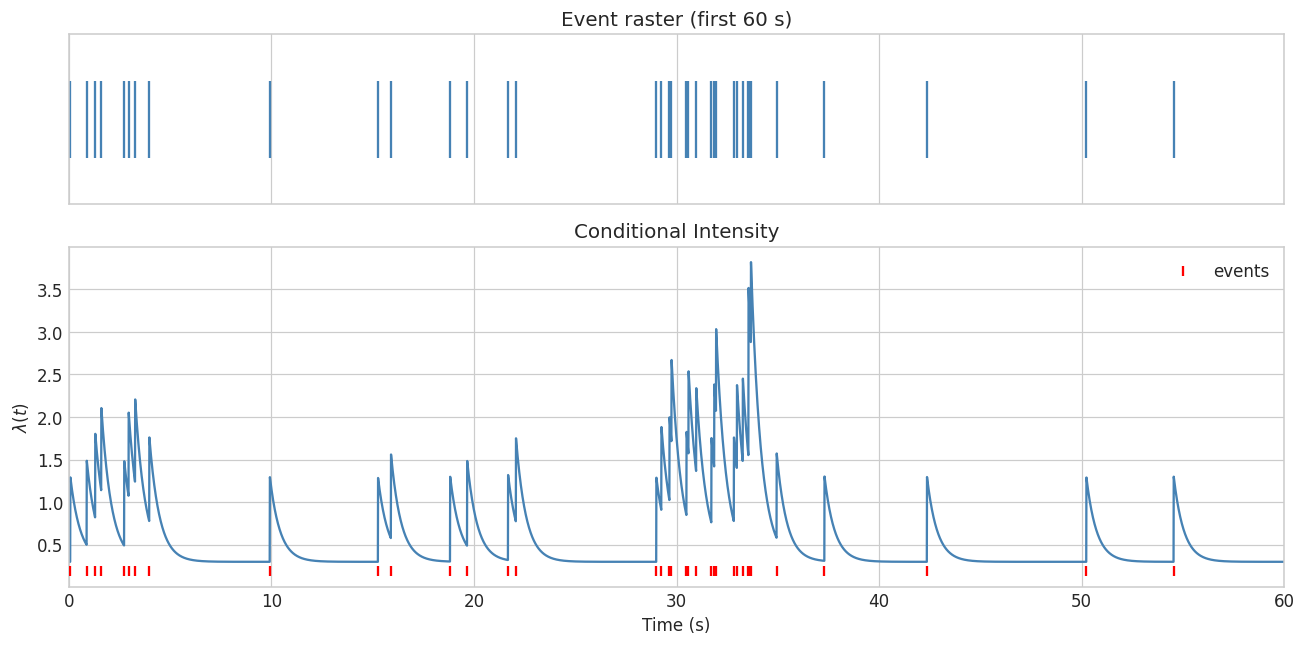

In [3]:
win = (0.0, 60.0)  # zoom to the first minute for readability
m = (events >= win[0]) & (events <= win[1])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2]})
axes[0].eventplot(events[m], lineoffsets=0, linelengths=0.8, color="steelblue")
axes[0].set_yticks([]); axes[0].set_title("Event raster (first 60 s)")

it.plot_intensity(
    it.FitResult(params=model.get_params(), log_likelihood=0.0,
                 process=model, events=events[m], T=win[1]),
    events=events[m], T=win[1], ax=axes[1],
)
axes[1].set_xlim(*win); axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$\lambda(t)$")
fig.tight_layout(); plt.show()

## 3. Clustering signature in the inter-event intervals

For a Poisson process the inter-event intervals (ISIs) are exponential with a
coefficient of variation (CV) of exactly 1. Self-excitation produces an
*excess* of very short intervals (within bursts) and of long ones (between
bursts), pushing the CV above 1 -- so the CV is a quick burstiness check.

ISI mean = 1.683s,  CV = 1.62  (Poisson CV = 1.0)


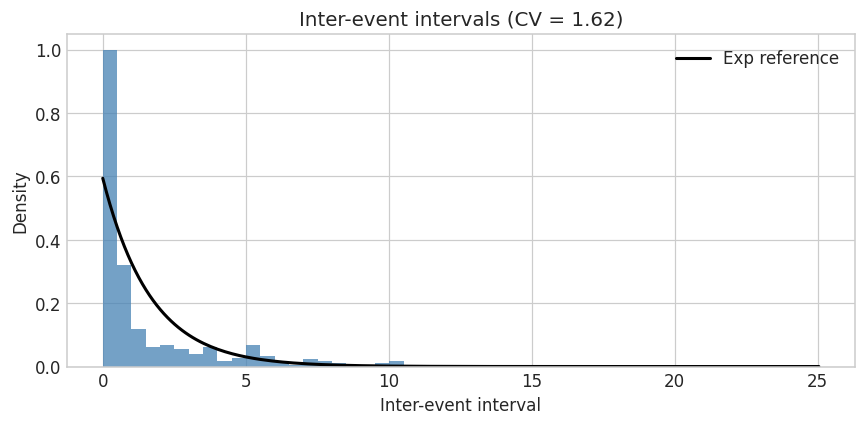

In [4]:
isi = np.diff(events)
cv = isi.std() / isi.mean()
print(f"ISI mean = {isi.mean():.3f}s,  CV = {cv:.2f}  (Poisson CV = 1.0)")

fig, ax = plt.subplots(figsize=(8, 4))
it.plot_inter_event_intervals(events, ax=ax, bins=50)
ax.set_title(f"Inter-event intervals (CV = {cv:.2f})")
plt.show()

## 4. Fit by maximum likelihood

`fit(..., method="mle")` maximises the exact Hawkes log-likelihood (evaluated
in the compiled Rust core). Starting values need only be in the right ballpark.

In [5]:
fit = it.UnivariateHawkes(mu=0.5, kernel=it.ExponentialKernel(alpha=0.3, beta=1.0))
result = fit.fit(events, T=T, method="mle")
print(result.summary())

FitResult:
  Log-likelihood: -449.8116
  AIC: 903.6233
  BIC: 911.3787
  Parameters:
    mu: 0.28927006443667974
    kernel: ExponentialKernel(alpha=0.5144943361870109, beta=1.7108718838720993)
  Standard errors:
    mu: 0.0295
    alpha: 0.0502
    beta: 0.2439
  Branching ratio: 0.5145
  Endogeneity index: 0.3397


In [6]:
params = result.flat_params()
print(f"{'param':<8}{'fitted':>10}{'true':>10}")
for k, true in [("mu", MU_TRUE), ("alpha", ALPHA_TRUE), ("beta", BETA_TRUE)]:
    print(f"{k:<8}{params[k]:>10.3f}{true:>10.3f}")

param       fitted      true
mu           0.289     0.300
alpha        0.514     0.500
beta         1.711     2.000


## 5. Interpreting the dynamics

The fitted branching ratio is the share of events that are *triggered* rather
than spontaneous; `endogeneity_index_` reports the same quantity as the
fraction of activity attributable to self-excitation cascades.

In [7]:
br = result.branching_ratio_
print(f"branching ratio      : {br:.3f}")
print(f"  -> each event triggers ~{br:.2f} children on average")
if result.endogeneity_index_ is not None:
    print(f"endogeneity index    : {result.endogeneity_index_:.3f}")
print(f"excitation timescale : {1/params['beta']*1000:.0f} ms  (1/beta)")
print(f"implied mean rate    : {params['mu']/(1-br):.3f} events/s")

branching ratio      : 0.514
  -> each event triggers ~0.51 children on average
endogeneity index    : 0.340
excitation timescale : 584 ms  (1/beta)
implied mean rate    : 0.596 events/s


## 6. Fitted intensity and triggering kernel

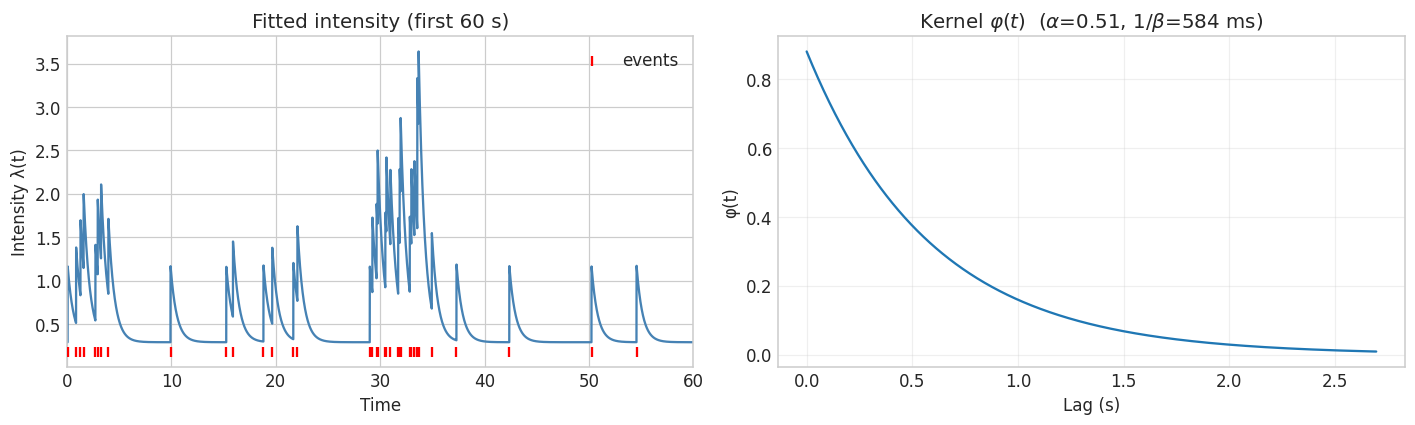

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
it.plot_intensity(result, events=events[m], T=win[1], ax=axes[0])
axes[0].set_xlim(*win); axes[0].set_title("Fitted intensity (first 60 s)")

it.plot_kernel(fit.kernel, ax=axes[1])
axes[1].set_title(rf"Kernel $\varphi(t)$  ($\alpha$={params['alpha']:.2f}, "
                  rf"$1/\beta$={1/params['beta']*1000:.0f} ms)")
axes[1].set_xlabel("Lag (s)")
fig.tight_layout(); plt.show()

## 7. Goodness of fit: the time-rescaling theorem

If the model is correct, the integrated intensity between consecutive events,
$\int_{t_{i-1}}^{t_i}\lambda(u)\,du$, yields i.i.d. $\mathrm{Exp}(1)$ samples
(the *time-rescaling theorem*). A Kolmogorov-Smirnov test and a QQ plot check
this. Because we simulated from the same model family, we expect a good fit.

KS statistic = 0.0320,  p-value = 0.847
adequate at 5%


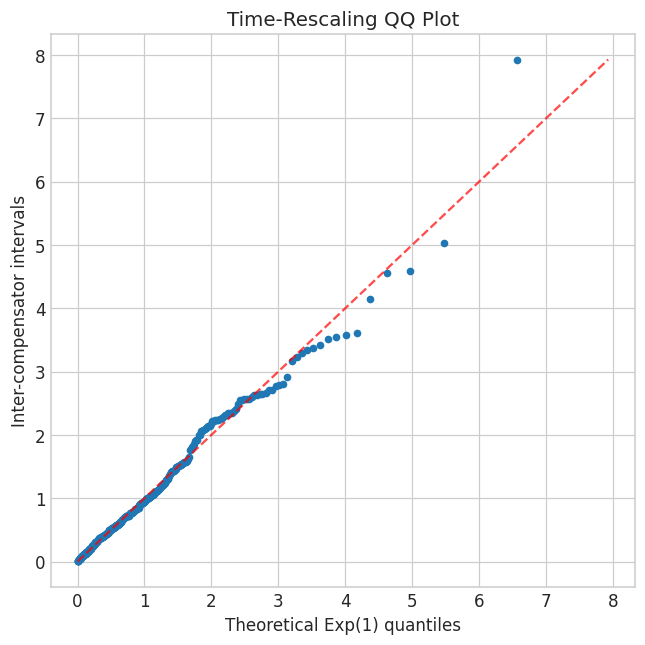

In [9]:
from intensify.core.diagnostics.goodness_of_fit import time_rescaling_test, qq_plot

ks, p = time_rescaling_test(result, events=events, T=T)
print(f"KS statistic = {ks:.4f},  p-value = {p:.3f}")
print("adequate at 5%" if p > 0.05 else "rejected at 5%")

qq_plot(result, events=events, T=T)
plt.show()

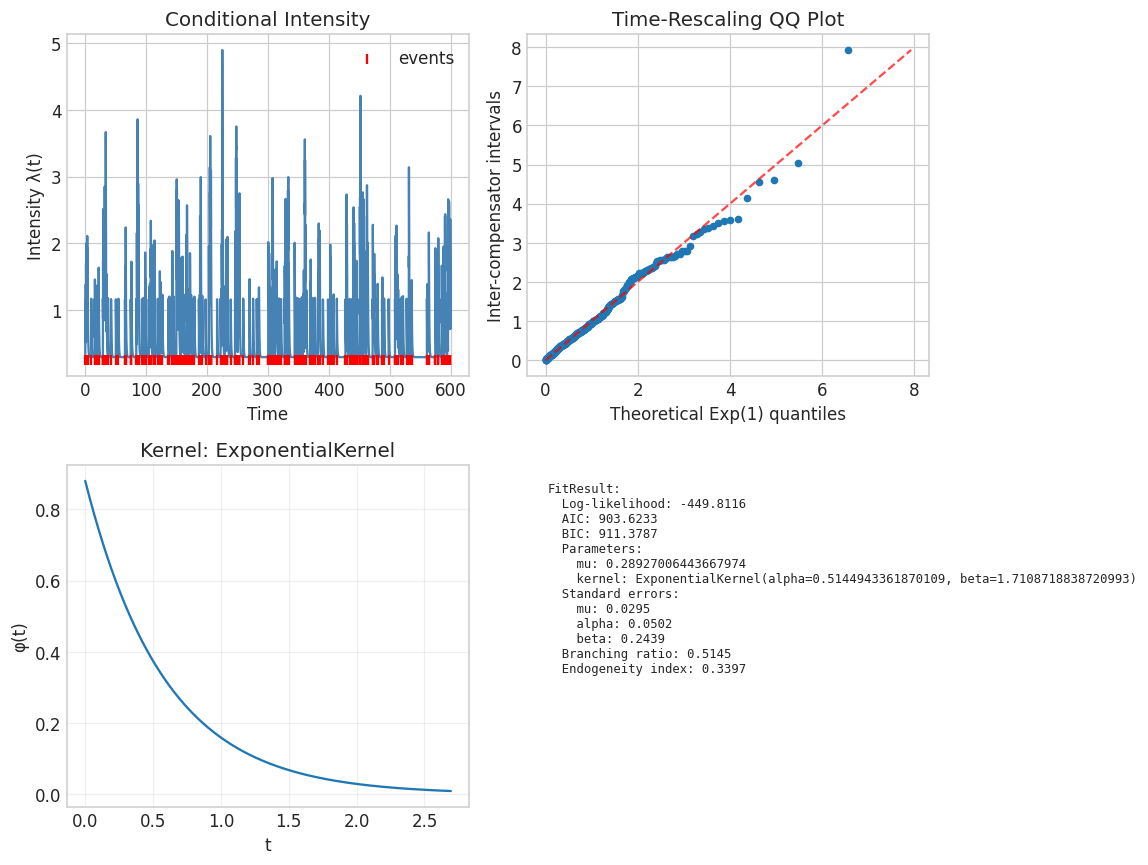

In [10]:
# The built-in panel bundles raster, intensity, rescaled-ISI and QQ diagnostics.
result.plot_diagnostics()
plt.show()

## 8. Parameter uncertainty via parametric bootstrap

MLE point estimates carry sampling error. A parametric bootstrap quantifies it
directly: repeatedly **simulate** new catalogues from the fitted model, refit
each, and look at the spread of estimates. This uses only the public
`simulate`/`fit` API and needs no extra dependencies.

In [11]:
B = 40
boot = {"mu": [], "alpha": [], "beta": []}
for b in range(B):
    sim = np.asarray(fit.simulate(T=T, seed=1000 + b))
    if len(sim) < 20:
        continue
    m_b = it.UnivariateHawkes(mu=0.4, kernel=it.ExponentialKernel(alpha=0.3, beta=1.5))
    p_b = m_b.fit(sim, T=T, method="mle").flat_params()
    for k in boot:
        boot[k].append(p_b[k])

print(f"{'param':<8}{'estimate':>10}{'95% CI':>22}")
for k, true in [("mu", MU_TRUE), ("alpha", ALPHA_TRUE), ("beta", BETA_TRUE)]:
    lo, hi = np.percentile(boot[k], [2.5, 97.5])
    print(f"{k:<8}{params[k]:>10.3f}   [{lo:6.3f}, {hi:6.3f}]   true={true}")

param     estimate                95% CI
mu           0.289   [ 0.216,  0.361]   true=0.3
alpha        0.514   [ 0.376,  0.599]   true=0.5
beta         1.711   [ 1.163,  2.198]   true=2.0


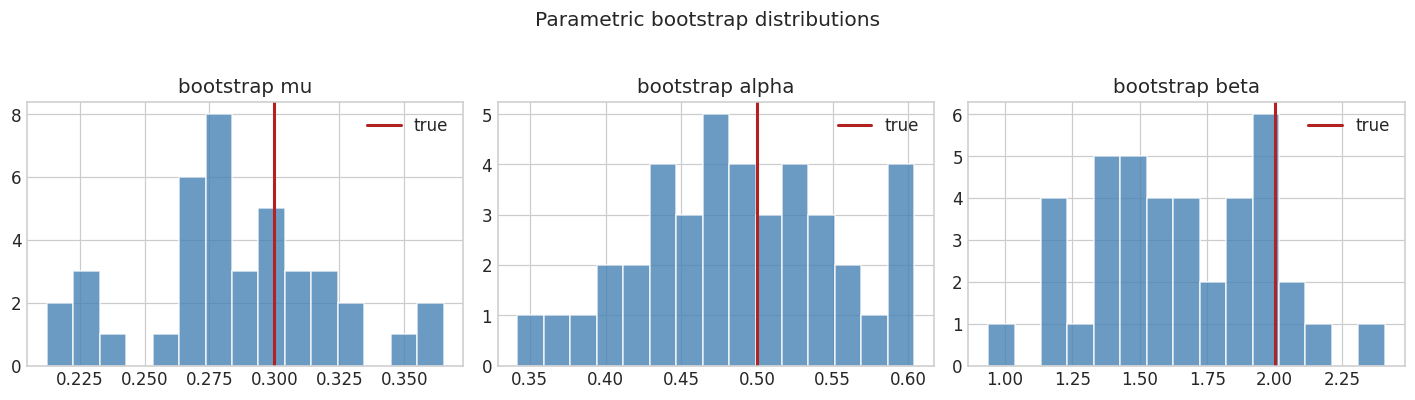

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, k, true in zip(axes, ["mu", "alpha", "beta"], [MU_TRUE, ALPHA_TRUE, BETA_TRUE]):
    ax.hist(boot[k], bins=15, color="steelblue", alpha=0.8, edgecolor="white")
    ax.axvline(true, color="firebrick", lw=2, label="true")
    ax.set_title(f"bootstrap {k}"); ax.legend()
fig.suptitle("Parametric bootstrap distributions", y=1.03)
fig.tight_layout(); plt.show()

## 9. Which kernel? Model selection

The exponential kernel decays geometrically; the **power-law** kernel
$\varphi(t) \propto (t + c)^{-(1+\beta)}$ captures heavy tails (e.g. Omori
decay in seismology). `ApproxPowerLawKernel` approximates a power law with a
sum of exponentials, keeping the $O(N)$ recursive likelihood. We compare them,
plus a Poisson null, by AIC/BIC (lower is better).

In [13]:
candidates = {
    "Poisson":            it.HomogeneousPoisson(),
    "Hawkes-exp":         it.UnivariateHawkes(mu=0.3, kernel=it.ExponentialKernel(alpha=0.3, beta=1.5)),
    "Hawkes-powerlaw":    it.UnivariateHawkes(mu=0.3, kernel=it.PowerLawKernel(alpha=0.3, beta=1.5, c=0.05)),
    "Hawkes-approx-pl":   it.UnivariateHawkes(mu=0.3, kernel=it.ApproxPowerLawKernel(alpha=0.3, beta_pow=1.5, beta_min=0.1, n_components=5)),
}

print(f"{'model':<20}{'loglik':>10}{'AIC':>10}{'BIC':>10}")
fits = {}
for name, mdl in candidates.items():
    r = mdl.fit(events, T=T) if name == "Poisson" else mdl.fit(events, T=T, method="mle")
    fits[name] = r
    print(f"{name:<20}{r.log_likelihood:>10.1f}{r.aic:>10.1f}{r.bic:>10.1f}")

model                   loglik       AIC       BIC
Poisson                 -542.4    1086.7    1090.6
Hawkes-exp              -449.8     903.6     911.4
Hawkes-powerlaw         -452.5     909.1     916.9
Hawkes-approx-pl        -449.8     903.6     911.4


The Hawkes models should crush the Poisson null (large drop in AIC),
confirming genuine self-excitation. Among Hawkes kernels the data here were
generated by an exponential, so it is typically favoured.

---
### Try it yourself
* Re-run with a near-critical branching ratio ($\alpha = 0.9$) and watch the
  CV and intensity bursts grow.
* Shrink `T` to 60 s and see how the bootstrap CIs widen.
* Swap in `it.SumExponentialKernel(alphas=[...], betas=[...])` for a
  multi-timescale kernel.

### Next steps
* **02_multivariate** -- coupled processes and connectivity inference.
* User guide: [inference](../docs/user_guide/inference.md),
  [kernels](../docs/user_guide/kernels.md),
  [diagnostics](../docs/user_guide/diagnostics.md).